In [1]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import load_img, img_to_array

In [ ]:
path = './Dataset'
label_list = []
for dirs in os.listdir(path):
    label_list.append(dirs)

images = []
classes = []
for i, label in enumerate(label_list):
    full_path = os.path.join(path, label)
    for j, image in enumerate(os.listdir(full_path)):
        img_path = os.path.join(full_path, image)
        img = load_img(img_path)
        img = img_to_array(img)
        img = tf.image.rgb_to_grayscale(img)
        img = img / 255

        images.append(img)
        classes.append(i)

In [3]:
y = tf.keras.utils.to_categorical(classes, len(label_list))
images = np.asarray(images)

In [4]:
x_train, x_temp, y_train, y_temp = train_test_split(images, y, train_size=0.8, random_state=42)
x_test, x_val, y_test, y_val = train_test_split(x_temp, y_temp, train_size=0.5, random_state=42)

In [5]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(16, activation='relu', kernel_size=(3, 3), strides=(1, 1), padding='same', input_shape=(224, 224, 1)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(16, activation='relu', kernel_size=(3, 3), strides=(1, 1), padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(4, activation='softmax'),
])

c:\Github\deep-learning\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)
history = model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=10,
    callbacks=early_stopping
)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.3481 - loss: 1.3887 - val_accuracy: 0.5400 - val_loss: 1.1543
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.5650 - loss: 0.9937 - val_accuracy: 0.6800 - val_loss: 0.8774
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.7819 - loss: 0.6296 - val_accuracy: 0.7800 - val_loss: 0.5882
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.8556 - loss: 0.4112 - val_accuracy: 0.8000 - val_loss: 0.5087
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.9112 - loss: 0.2587 - val_accuracy: 0.8150 - val_loss: 0.5249
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.9419 - loss: 0.1692 - val_accuracy: 0.8400 - val_loss: 0.5198
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.9613 - loss: 0.1160 - val_accuracy: 0.8600 - val_loss: 0.4581
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.9744 - loss: 0.0785 - val_accuracy: 0.8100 - v

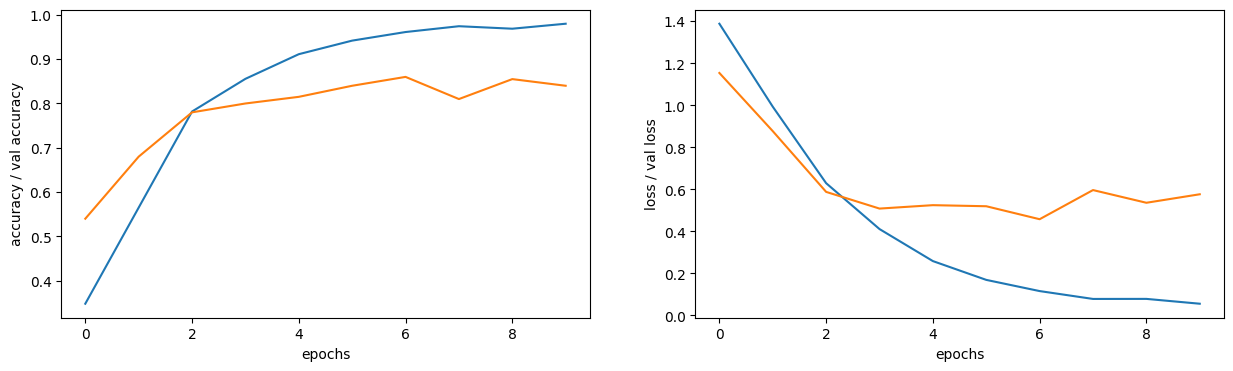

In [8]:
plt.figure(figsize=(15, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('epochs')
plt.ylabel('accuracy / val accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss / val loss')

plt.show()

In [9]:
loss, accuracy = model.evaluate(x_test, y_test, verbose=2)
print('test loss:', loss)
print('test accuracy:', accuracy)

y_preds_probs = model.predict(x_test)
y_pred = np.argmax(y_preds_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred, target_names=label_list))

7/7 - 0s - 16ms/step - accuracy: 0.9000 - loss: 0.3463
test loss: 0.3463175594806671
test accuracy: 0.8999999761581421
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
              precision    recall  f1-score   support

    Broccoli       0.85      0.96      0.90        54
      Carrot       0.93      0.98      0.95        53
    Cucumber       0.88      0.90      0.89        41
      Tomato       0.95      0.75      0.84        52

    accuracy                           0.90       200
   macro avg       0.90      0.90      0.90       200
weighted avg       0.90      0.90      0.90       200

